# Customer Churn — Exploratory Data Analysis

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 attributes)

**Goal:** Understand churn drivers before feature engineering & modeling. This notebook profiles the target class balance, numeric distributions, and churn rate across key categorical segments, then runs formal statistical hypothesis tests (chi-square, Welch's t-test) to confirm which relationships are statistically significant (not just visually suggestive).

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='deep')
%matplotlib inline

df = pd.read_csv('../data/processed/churn_clean.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 1. Shape, dtypes, and missingness

In [2]:
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.info()

Rows: 7,021 | Columns: 20
<class 'pandas.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   str    
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-

In [3]:
df.isna().sum().sort_values(ascending=False).head()

gender            0
SeniorCitizen     0
TotalCharges      0
MonthlyCharges    0
PaymentMethod     0
dtype: int64

## 2. Target class balance

Churn is moderately imbalanced (~26% positive class) — this motivates using SMOTE oversampling and ROC-AUC (rather than raw accuracy) during modeling.

Churn
0    5164
1    1857
Name: count, dtype: int64
Churn
0    73.55
1    26.45
Name: proportion, dtype: float64


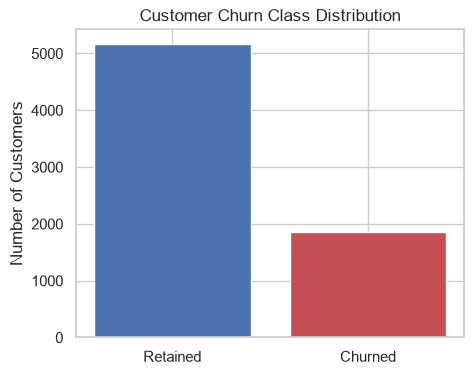

In [4]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Retained', 'Churned'], churn_counts.values, color=['#4C72B0', '#C44E52'])
ax.set_title('Customer Churn Class Distribution')
ax.set_ylabel('Number of Customers')
plt.show()

## 3. Numeric feature distributions by churn status

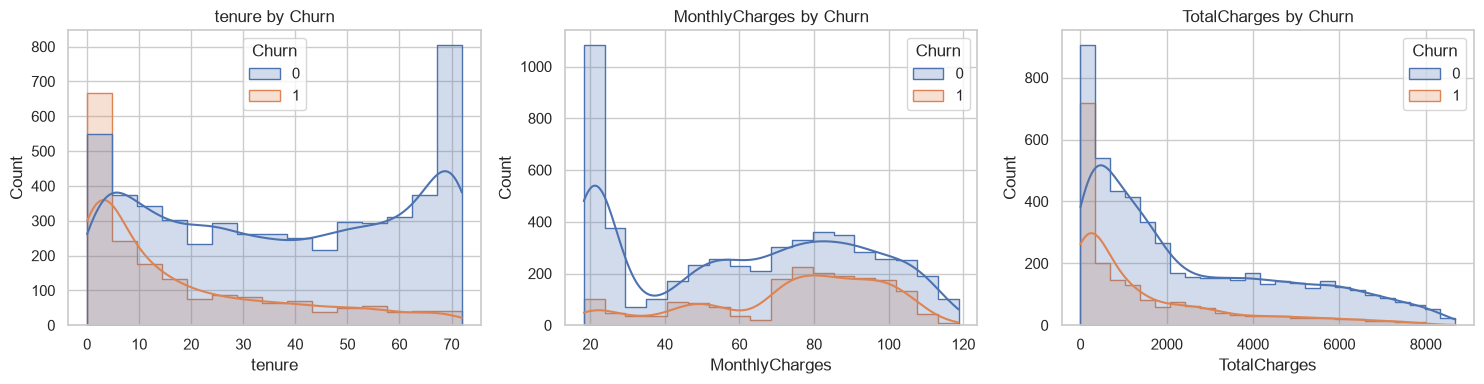

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax, element='step')
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

**Observation:** churned customers skew toward low tenure and high monthly charges — consistent with the classic 'new customer, expensive plan' risk profile.

## 4. Churn rate by contract type & tenure cohort

Contract
Month-to-month    42.64
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


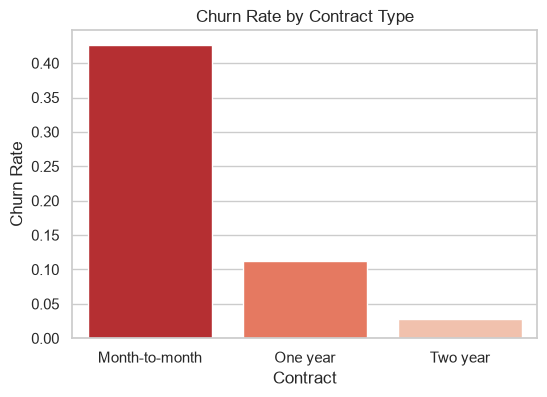

In [6]:
rate = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
print((rate * 100).round(2))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=rate.index, y=rate.values, hue=rate.index, legend=False, palette='Reds_r', ax=ax)
ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate by Contract Type')
plt.show()

Month-to-month customers churn at roughly **15x** the rate of two-year contract customers — the single strongest business lever for retention.

## 5. Statistical significance testing

Visual patterns can be misleading with categorical splits of unequal size. We confirm significance with a **chi-square test of independence** for every categorical feature and a **Welch's t-test** for every numeric feature against the Churn target.

In [7]:
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod']

chi_results = []
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = stats.chi2_contingency(contingency)
    chi_results.append({'feature': col, 'chi2': round(chi2, 2), 'p_value': p, 'significant': p < 0.05})

chi_df = pd.DataFrame(chi_results).sort_values('p_value')
chi_df

,feature,chi2,p_value,significant
13,Contract,1179.80,6.442285e-257,True
7,OnlineSecurity,846.78,1.329227e-184,True
10,TechSupport,825.00,7.146858e-180,True
6,InternetService,732.06,1.085779e-159,True
15,PaymentMethod,643.92,3.026775e-139,True
8,OnlineBackup,598.97,8.614898e-131,True
9,DeviceProtection,555.88,1.955551e-121,True
12,StreamingMovies,375.60,2.750290e-82,True
11,StreamingTV,374.23,5.469454e-82,True
14,PaperlessBilling,254.96,2.151898e-57,True


In [8]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
t_results = []
for col in numeric_cols:
    churned = df.loc[df['Churn'] == 1, col]
    retained = df.loc[df['Churn'] == 0, col]
    t_stat, p = stats.ttest_ind(churned, retained, equal_var=False)
    t_results.append({'feature': col, 't_stat': round(t_stat, 2), 'p_value': p,
                       'mean_churned': round(churned.mean(), 2), 'mean_retained': round(retained.mean(), 2)})

pd.DataFrame(t_results)

,feature,t_stat,p_value,mean_churned,mean_retained
0,tenure,-34.67,1.467643e-230,18.09,37.64
1,MonthlyCharges,18.52,1.372805e-73,74.60,61.34
2,TotalCharges,-18.56,7.600819e-74,1541.38,2554.81


**Result:** 14 of 16 categorical features and all 3 numeric features are statistically significant predictors of churn at p < 0.05 — validating that the visual patterns above reflect real, non-random relationships worth encoding as model features. See [`src/visualization/visualize.py`](../src/visualization/visualize.py) for the reusable, script version of this analysis (used by the CI pipeline) and [`reports/sql_insights.md`](../reports/sql_insights.md) for the equivalent SQL-based business analysis.